# Feature selection + Supervised learning

Inputs: data/clean.parquet

Outputs:
- outputs/evidence_model.json
- outputs/cv_results.csv
- outputs/rq_experiments.csv
- outputs/feature_ranking.csv
- outputs/fs_validation.csv
- outputs/fig_confusion.png
- outputs/fig_importance.png

### Section 0: Setup

In [22]:
import json
import os
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Constants:
PROJECT_ROOT = pathlib.Path().resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_DIR = PROJECT_ROOT / "data"
DEFAULT_ROUNDING_DECIMALS = 4
RANDOM_SEED = 20008


# Utility function used to round a value to a given number of places
def round_value(value, digits=DEFAULT_ROUNDING_DECIMALS):
    return round(float(value), digits)


evidence = {}

# Listings dataframe
listings = pd.read_parquet(DATA_DIR / "clean.parquet")
listings["room_type_3"] = listings["room_type"].replace({"Shared room": "Other", "Hotel room": "Other"})

fundamentals = ["room_type_3", "dist_cbd", "accommodates"]
operationals = ["availability_365", "amenity_count", "days_since_last_review", "has_review", "price_num", "price_missing", "minimum_nights", "host_listings_count"]
ALL_FEATURES = fundamentals + operationals
X, y, host_ids = listings[ALL_FEATURES], listings["y"], listings["host_id"]

os.makedirs(OUTPUT_DIR, exist_ok=True)

### Section 1: Stratified split by host

In [23]:
# Separate group into 5 folds:
group_kfold_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
# One fold becomes test set:
train_row_positions, test_row_positions = next(group_kfold_splitter.split(X, y, groups=host_ids))

# Training set and test set separation:
X_train, X_test = (
    X.iloc[train_row_positions],
    X.iloc[test_row_positions],
)
y_train, y_test = y.iloc[train_row_positions], y.iloc[test_row_positions]
host_ids_train, host_ids_test = (
    host_ids.iloc[train_row_positions],
    host_ids.iloc[test_row_positions],
)

evidence["split"] = {
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "test_share": round_value(len(X_test) / len(X)),
    "train_hosts": int(host_ids_train.nunique()),
    "test_hosts": int(host_ids_test.nunique()),
    "train_pos_rate": round_value(y_train.mean()),
    "test_pos_rate": round_value(y_test.mean()),
    "host_overlap": len(set(host_ids_train) & set(host_ids_test)),
}

print("Split information")
evidence["split"]

Split information


{'train_rows': 20582,
 'test_rows': 5146,
 'test_share': 0.2,
 'train_hosts': 11292,
 'test_hosts': 2821,
 'train_pos_rate': 0.3065,
 'test_pos_rate': 0.3065,
 'host_overlap': 0}

### Section 2: Pipeline initialisation

In [24]:
def build_preprocessor(feature_list, scale=False):
    """
    Builds a preprocessor for a given column.
    For numeric columns, impute the median using the training dataset
    For room type, the data is one-hot encoded

    Args:
        feature_list: the column data
        scale: Whether to standardise the column or not (using StandardScaler). Defaults to False.

    Returns:
        A sklearn column transformer object
    """

    # Numeric features are all features except for room type
    numeric_features = [column for column in feature_list if column != "room_type_3"]
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    transformer_branches = [("num", Pipeline(numeric_steps), numeric_features)] if numeric_features else []
    if "room_type_3" in feature_list:
        transformer_branches.append(("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["room_type_3"]))
    return ColumnTransformer(transformer_branches)


def build_model(model_name: str, feature_list: list[str], hyperparameter):
    """Builds a model via preprocessor and classifier.

    Args:
        model_name: Either 'KNN' for kNN or 'DT' for decision tree
        feature_list: a string list of features to train on
        hyperparameter: the hyperparameter corresponding to model name.
        - For KNN it is k.
        - For decision tree it is tree depth
    """
    if model_name == "KNN":
        return Pipeline(
            [
                # Requires a scaling step because kNN judges by distance
                ("prep", build_preprocessor(feature_list, scale=True)),
                ("model", KNeighborsClassifier(n_neighbors=hyperparameter)),
            ]
        )
    elif model_name == "DT":
        return Pipeline(
            [
                (
                    "prep",
                    build_preprocessor(feature_list, scale=False),
                ),
                ("model", DecisionTreeClassifier(max_depth=hyperparameter, random_state=RANDOM_SEED)),
            ]
        )
    else:
        raise Exception("Unknown model type:", model_name)


def cross_validate_f1(model, feature_list: list[str]):
    """
    Runs 5-fold Cross Validation on the training set

    Args:
        model: The model object itself
        feature_list: The list of features

    Returns:
        Five F1 scores
    """

    return cross_val_score(
        model,
        X_train[feature_list],
        y_train,
        groups=host_ids_train,
        cv=group_kfold_splitter,
        scoring="f1",
        n_jobs=-1,
    )

## Section 3. Baseline + Tuning

In [25]:
# Each candidate value gets one 5-fold CV run.
tuning_rows = []

# Baseline scores: model will predict 0 every time
fold_scores = cross_validate_f1(DummyClassifier(strategy="most_frequent"), ALL_FEATURES)
# Append distribution information
tuning_rows.append({"model": "Baseline", "param": "-", "cv_mean": fold_scores.mean(), "cv_std": fold_scores.std()})

HYPERPARAMETER_GRID = {
    # Hyperparamer 'k' for kNN
    "KNN": [1, 5, 11, 21, 51, 101, 151, 201, 301],
    # Hyperparameter tree depth for decision trees
    # None means no limit, ending with a rule per listing (overfit)
    "DT": [2, 3, 4, 5, 6, 8, 10, 15, None],
}

for model_name, candidate_values in HYPERPARAMETER_GRID.items():
    for hyperparameter in candidate_values:
        # Calculate cross validation scores:
        fold_scores = cross_validate_f1(build_model(model_name, ALL_FEATURES, hyperparameter), ALL_FEATURES)
        # Calculate the distribution info of the scores:
        tuning_rows.append({"model": model_name, "param": hyperparameter, "cv_mean": fold_scores.mean(), "cv_std": fold_scores.std()})

# This table reports every candidates cross validation score
tuning_table = pd.DataFrame(tuning_rows)

# Find the best hyperparameters by CV mean
best_hyperparameters = {}
best_model_name = ""
for model_name in HYPERPARAMETER_GRID:
    model_rows = [row for row in tuning_rows if row["model"] == model_name]
    if model_rows:
        best_row = max(model_rows, key=lambda row: row["cv_mean"])
        best_model_name = str(best_row["model"])
        best_hyperparameters[model_name] = best_row["param"]

assert best_model_name != ""
evidence["best_param"], evidence["best_model"] = best_hyperparameters, best_model_name
print(tuning_table.round(4).to_string(index=False))
print("Best model:", best_model_name)
print("Best hyperparameters:")
best_hyperparameters

   model param  cv_mean  cv_std
Baseline     -   0.0000  0.0000
     KNN     1   0.4802  0.0175
     KNN     5   0.5020  0.0159
     KNN    11   0.5071  0.0176
     KNN    21   0.5190  0.0112
     KNN    51   0.5299  0.0121
     KNN   101   0.5370  0.0133
     KNN   151   0.5312  0.0147
     KNN   201   0.5309  0.0175
     KNN   301   0.5249  0.0226
      DT     2   0.5158  0.0503
      DT     3   0.5611  0.0431
      DT     4   0.5712  0.0177
      DT     5   0.5384  0.0424
      DT     6   0.5512  0.0240
      DT     8   0.5622  0.0123
      DT    10   0.5745  0.0130
      DT    15   0.5363  0.0171
      DT  None   0.5018  0.0072
Best model: DT
Best hyperparameters:


{'KNN': 101, 'DT': 10}

### Section 4: Final test-set evaluation


==== Baseline ====
              precision    recall  f1-score   support

           0      0.694     1.000     0.819      3569
           1      0.000     0.000     0.000      1577

    accuracy                          0.694      5146
   macro avg      0.347     0.500     0.410      5146
weighted avg      0.481     0.694     0.568      5146


==== KNN ====
              precision    recall  f1-score   support

           0      0.811     0.832     0.821      3569
           1      0.596     0.560     0.577      1577

    accuracy                          0.749      5146
   macro avg      0.703     0.696     0.699      5146
weighted avg      0.745     0.749     0.746      5146


==== DT ====
              precision    recall  f1-score   support

           0      0.845     0.807     0.825      3569
           1      0.603     0.664     0.632      1577

    accuracy                          0.763      5146
   macro avg      0.724     0.735     0.729      5146
weighted avg      0.770  

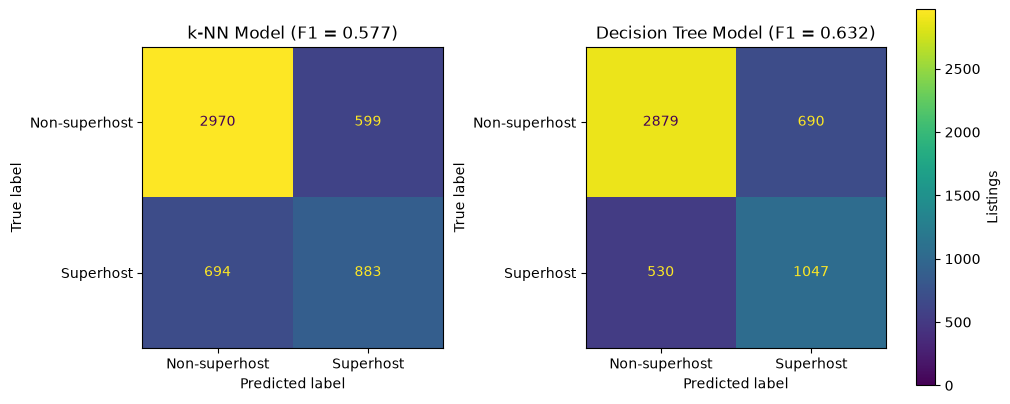

In [26]:
# Best models with specified best hyperparameters
final_models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "KNN": build_model("KNN", ALL_FEATURES, best_hyperparameters["KNN"]),
    "DT": build_model("DT", ALL_FEATURES, best_hyperparameters["DT"]),
}

# Test set predictions
test_predictions = {}
# Test prediction metrics (f1 and accuracy)
evidence["test"] = {}

for model_name, model in final_models.items():
    # Train the model on the given data:
    test_predictions[model_name] = model.fit(X_train, y_train).predict(X_test)
    report = classification_report(y_test, test_predictions[model_name], digits=3, zero_division=0, output_dict=True)

    # Build the base metrics
    model_evidence = {
        "f1": round_value(report["1"]["f1-score"]),
        "accuracy": round_value(report["accuracy"]),
    }

    # Add per-class metrics
    for label in ("0", "1"):
        model_evidence[f"class_{label}"] = {metric: round_value(report[label][metric]) for metric in ("precision", "recall", "f1-score")}

    evidence["test"][model_name] = model_evidence

    print(f"\n==== {model_name} ====")
    print(classification_report(y_test, test_predictions[model_name], digits=3, zero_division=0))

# Generate kNN and DT confusion matrices
confusion_matrices = {model_name: confusion_matrix(y_test, test_predictions[model_name]) for model_name in ("KNN", "DT")}
shared_max = max(matrix.max() for matrix in confusion_matrices.values())

figure, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
model_name_formatted = {
    "KNN": "k-NN Model",
    "DT": "Decision Tree Model"
}
for axis, model_name in zip(axes, ["KNN", "DT"]):
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions[model_name], ax=axis, colorbar=False, display_labels=["Non-superhost", "Superhost"], im_kw={"vmin": 0, "vmax": shared_max})
    axis.set_title(f"{model_name_formatted[model_name]} (F1 = {evidence['test'][model_name]['f1']:.3f})")  # ty:ignore[not-subscriptable]
figure.colorbar(axes[1].images[0], ax=axes, fraction=0.046, pad=0.04, label="Listings")
plt.savefig(os.path.join(OUTPUT_DIR, "fig_confusion.png"), dpi=150, bbox_inches="tight")
plt.close(figure)

y_test_array = y_test.to_numpy()
test_rows_by_host = list(host_ids_test.reset_index(drop=True).groupby(host_ids_test.to_numpy()).indices.values())


# Paired bootstrap comparison
def bootstrap_compare(predictions_a, predictions_b, n_resamples=1000):
    """
    Compare two models with bootstraping.

    Resamples the hosts with replacement n_resamples times, scoring both
    models on each identical resample, and returns the 95% percentile interval for
    each model's F1 score.
    """
    rng = np.random.default_rng(RANDOM_SEED)
    scores_a, scores_b = [], []
    for _ in range(n_resamples):
        sampled_hosts = rng.integers(len(test_rows_by_host), size=len(test_rows_by_host))
        sampled_rows = np.concatenate([test_rows_by_host[host] for host in sampled_hosts])
        scores_a.append(f1_score(y_test_array[sampled_rows], predictions_a[sampled_rows]))
        scores_b.append(f1_score(y_test_array[sampled_rows], predictions_b[sampled_rows]))

    def confidence_interval(scores):
        # Generate a confidence 95% interval from the provided argument
        return  [round_value(bound) for bound in np.percentile(scores, [2.5, 97.5])]
    
    return {
        "a": confidence_interval(scores_a),
        "b": confidence_interval(scores_b),
        "b_minus_a": confidence_interval(np.array(scores_b) - np.array(scores_a)),
    }


evidence["boot_KNN_vs_DT"] = bootstrap_compare(test_predictions["KNN"], test_predictions["DT"])
print("\nbootstrap KNN vs DT:")
evidence["boot_KNN_vs_DT"]
figure

### Section 5: Experiments. 

Shows model only part of the features and sees what it scores.

In [27]:
REVIEW_FEATURES = [
    "days_since_last_review",
    "has_review",
]
FEATURE_SETS = {
    # Fundamentals only
    "A_fundamentals": fundamentals,
    # Operational only
    "B_operational": operationals,
    # Control group: All features, identical to our final model
    "C_all": ALL_FEATURES,
    # All features except days_since_last_review and has_review
    # Determines whether review recency has any relevance
    "D_all_no_review": [column for column in ALL_FEATURES if column not in REVIEW_FEATURES],
    # All features except availability_365
    "E_all_no_avail": [column for column in ALL_FEATURES if column != "availability_365"],
    # Operational only except days_since_last_review and has_review
    "F_operational_no_review": [column for column in operationals if column not in REVIEW_FEATURES],
}


def run_feature_sets(feature_sets):
    """
    For each feature set and each of the two models, calculate:
    - CV score
    - test score
    """
    result_rows, predictions = [], {}
    for experiment_name, feature_list in feature_sets.items():
        for model_name in ("KNN", "DT"):
            # Build model on restricted feature set
            model = build_model(model_name, feature_list, best_hyperparameters[model_name])
            # 5-Fold CV on training set
            fold_scores = cross_validate_f1(model, feature_list)
            # Train and predict
            predictions[experiment_name, model_name] = model.fit(X_train[feature_list], y_train).predict(X_test[feature_list])
            result_rows.append(
                {
                    "experiment": experiment_name,
                    "model": model_name,
                    "n_features": len(feature_list),
                    "cv_mean": fold_scores.mean(),
                    "cv_std": fold_scores.std(),
                    "test_f1": f1_score(y_test, predictions[experiment_name, model_name]),
                }
            )
    return pd.DataFrame(result_rows), predictions


rq_experiment_table, rq_test_predictions = run_feature_sets(FEATURE_SETS)
evidence["rq"] = rq_experiment_table.round(4).to_dict("records")
evidence["boot_A_vs_B"] = bootstrap_compare(rq_test_predictions["A_fundamentals", best_model_name], rq_test_predictions["B_operational", best_model_name])
evidence["boot_A_vs_F"] = bootstrap_compare(rq_test_predictions["A_fundamentals", best_model_name], rq_test_predictions["F_operational_no_review", best_model_name])

print("\n", rq_experiment_table.pivot(index="experiment", columns="model", values="cv_mean").round(4))
print("A vs B:", evidence["boot_A_vs_B"])
print("A vs F:", evidence["boot_A_vs_F"])


 model                        DT     KNN
experiment                             
A_fundamentals           0.1658  0.1610
B_operational            0.5484  0.5402
C_all                    0.5745  0.5370
D_all_no_review          0.5262  0.5032
E_all_no_avail           0.5846  0.5263
F_operational_no_review  0.5288  0.4947
A vs B: {'a': [0.1535, 0.2384], 'b': [0.5981, 0.6844], 'b_minus_a': [0.3813, 0.5046]}
A vs F: {'a': [0.1535, 0.2384], 'b': [0.4923, 0.6313], 'b_minus_a': [0.2819, 0.4536]}


### Section 6: Feature influence

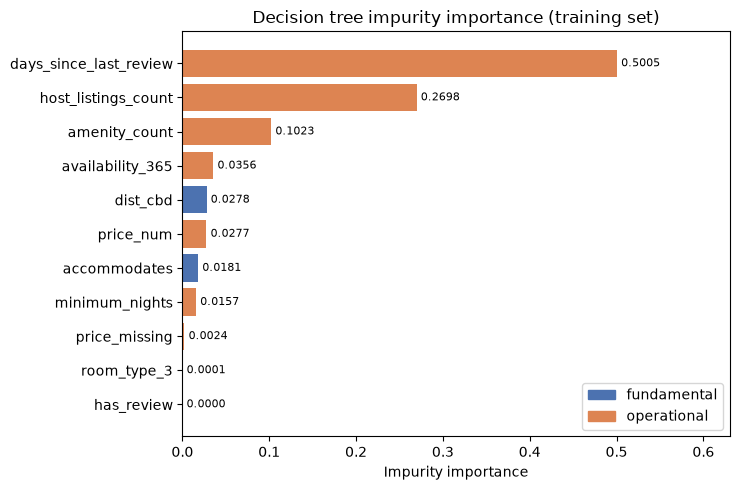

In [28]:
final_tree_pipeline = final_models["DT"]
transformed_feature_names = final_tree_pipeline.named_steps["prep"].get_feature_names_out()
tree_builtin_importance = (
    pd.Series(
        final_tree_pipeline.named_steps["model"].feature_importances_,
        index=["room_type_3" if name.startswith("cat__") else name[5:] for name in transformed_feature_names],
    )
    .groupby(level=0)
    .sum()
)

feature_ranking_table = pd.DataFrame(
    {
        "group": ["fundamental" if column in fundamentals else "operational" for column in ALL_FEATURES],
        "DT_builtin": tree_builtin_importance,
    },
    index=ALL_FEATURES,
)

# Separate groups via distinct colors
GROUP_COLORS = {"fundamental": "#4C72B0", "operational": "#DD8452"}

figure, axis = plt.subplots(figsize=(7.5, 5))
sorted_table = feature_ranking_table.sort_values("DT_builtin")
importance_bars = axis.barh(sorted_table.index, sorted_table["DT_builtin"], color=sorted_table["group"].map(GROUP_COLORS))
axis.bar_label(importance_bars, labels=[f"{value:.4f}" for value in sorted_table["DT_builtin"]], padding=3, fontsize=8)
# Headroom so the label on the longest bar is not clipped by the axis
axis.set(title="Decision tree impurity importance (training set)", xlabel="Impurity importance", xlim=(0, sorted_table["DT_builtin"].max() * 1.26))
axis.legend(handles=[Patch(color=color, label=group) for group, color in GROUP_COLORS.items()], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_importance.png"), dpi=150)
plt.close(figure)

figure

### Section 7. Feature selection

In [29]:
X_train_for_mutual_info = X_train.copy()  # Copy of training data
X_train_for_mutual_info["room_type_3"] = X_train_for_mutual_info["room_type_3"].astype("category").cat.codes
X_train_for_mutual_info = X_train_for_mutual_info.fillna(X_train_for_mutual_info.median())
feature_ranking_table["filter_MI"] = mutual_info_classif(
    X_train_for_mutual_info,
    y_train,
    random_state=RANDOM_SEED,
    discrete_features=[column in ("room_type_3", "has_review", "price_missing") for column in ALL_FEATURES],
)

feature_ranking_table["filter_rank"] = feature_ranking_table["filter_MI"].rank(ascending=False, method="min").astype(int)
feature_ranking_table["embedded_rank"] = feature_ranking_table["DT_builtin"].rank(ascending=False, method="min").astype(int)
top3_features = {
    "filter_top3": feature_ranking_table["filter_MI"].nlargest(3).index.tolist(),
    "embedded_top3": feature_ranking_table["DT_builtin"].nlargest(3).index.tolist(),
}

feature_selection_validation_table, _ = run_feature_sets(top3_features)
feature_selection_validation_table = pd.concat([feature_selection_validation_table, rq_experiment_table[rq_experiment_table["experiment"] == "C_all"]], ignore_index=True)
evidence["top3"] = top3_features
evidence["top3_common"] = sorted(set(top3_features["filter_top3"]) & set(top3_features["embedded_top3"]))
evidence["feature_ranking"] = feature_ranking_table.round(4).to_dict("index")
evidence["fs_validation"] = feature_selection_validation_table.round(4).to_dict("records")

print("\n", feature_ranking_table.sort_values("filter_rank").round(4).to_string()) 
print(feature_selection_validation_table.round(4).to_string(index=False))
top3_features


                               group  DT_builtin  filter_MI  filter_rank  embedded_rank
days_since_last_review  operational      0.5005     0.1273            1              1
host_listings_count     operational      0.2698     0.1087            2              2
availability_365        operational      0.0356     0.0759            3              4
amenity_count           operational      0.1023     0.0749            4              3
price_num               operational      0.0277     0.0657            5              6
price_missing           operational      0.0024     0.0451            6              9
has_review              operational      0.0000     0.0344            7             11
dist_cbd                fundamental      0.0278     0.0340            8              5
minimum_nights          operational      0.0157     0.0097            9              8
room_type_3             fundamental      0.0001     0.0089           10             10
accommodates            fundamental      

{'filter_top3': ['days_since_last_review',
  'host_listings_count',
  'availability_365'],
 'embedded_top3': ['days_since_last_review',
  'host_listings_count',
  'amenity_count']}

### Section 8: Hard-case analysis

In [30]:
test_detail_table = X_test.assign(
    y_true=y_test,
    y_pred=test_predictions[best_model_name],
    proba=final_models[best_model_name].predict_proba(X_test)[:, 1],
    id=listings.loc[X_test.index, "id"],
    host_id=host_ids_test,
)
false_negatives = test_detail_table[(test_detail_table["y_true"] == 1) & (test_detail_table["y_pred"] == 0)].sort_values("proba", kind="stable")
hard_case = false_negatives.iloc[0]

median_comparison_table = X_train.groupby(y_train).median(numeric_only=True).T
median_comparison_table.columns = ["non_superhost_median", "superhost_median"]
median_comparison_table["this_listing"] = hard_case[median_comparison_table.index].astype(float)

hard_case_host_listings = listings[listings["host_id"] == hard_case["host_id"]]
evidence["hard_case"] = {
    "listing_id": int(hard_case["id"]),
    "host_id": int(hard_case["host_id"]),
    "model": best_model_name,
    "proba_superhost": round_value(hard_case["proba"]),
    "room_type": hard_case["room_type_3"],
    "fn_total": len(false_negatives),
    "listing_number_of_reviews": int(listings.loc[hard_case.name, "number_of_reviews"]),
    "host_n_listings": len(hard_case_host_listings),
    "host_listings_with_reviews": int(hard_case_host_listings["has_review"].sum()),
    "comparison": median_comparison_table.round(2).to_dict("index"),
}
print("\n", {key: value for key, value in evidence["hard_case"].items() if key != "comparison"}, "\n", median_comparison_table.round(2))

true_positives = test_detail_table[(test_detail_table["y_true"] == 1) & (test_detail_table["y_pred"] == 1)]
inactive_over_year = test_detail_table["days_since_last_review"] > 365
evidence["false_negative_context"] = {
    "test_superhosts_inactive_over_year": int((inactive_over_year & (test_detail_table["y_true"] == 1)).sum()),
    "false_negatives_inactive_over_year": int(inactive_over_year[false_negatives.index].sum()),
    "false_negatives_no_review": int((false_negatives["has_review"] == 0).sum()),
    "false_negative_median_dsl": round_value(false_negatives["days_since_last_review"].median(), 1),
    "true_positive_median_dsl": round_value(true_positives["days_since_last_review"].median(), 1),
}
print("false negative context:", evidence["false_negative_context"])


 {'listing_id': 6812677, 'host_id': 35667203, 'model': 'DT', 'proba_superhost': 0.0, 'room_type': 'Entire home/apt', 'fn_total': 530, 'listing_number_of_reviews': 195, 'host_n_listings': 1, 'host_listings_with_reviews': 1} 
                         non_superhost_median  superhost_median  this_listing
dist_cbd                                4.92              4.64          3.71
accommodates                            3.00              4.00          4.00
availability_365                      124.00            195.00        116.00
amenity_count                          32.00             45.00         18.00
days_since_last_review                468.00             37.00        156.00
has_review                              1.00              1.00          1.00
price_num                             240.00            252.00        261.00
price_missing                           0.00              0.00          0.00
minimum_nights                          2.00              2.00          2.00
host

In [31]:
# Tables
tuning_table.round(4).to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
rq_experiment_table.round(4).to_csv(OUTPUT_DIR / "rq_experiments.csv", index=False)
feature_ranking_table.round(4).to_csv(OUTPUT_DIR / "feature_ranking.csv")
feature_selection_validation_table.round(4).to_csv(OUTPUT_DIR / "fs_validation.csv", index=False)

with open(os.path.join(OUTPUT_DIR, "evidence_model.json"), "w") as evidence_file:
    json.dump(evidence, evidence_file, indent=2, ensure_ascii=False, default=str)